### 8. Pytorch paper replicating

In this project, we're going to be replicating a machine learning research paper and creating a Vision Transformer (ViT) from scratch using PyTorch.

We'll then see how ViT, a state-of-the-art computer vision architecture, performs on our FoodVision Mini problem.



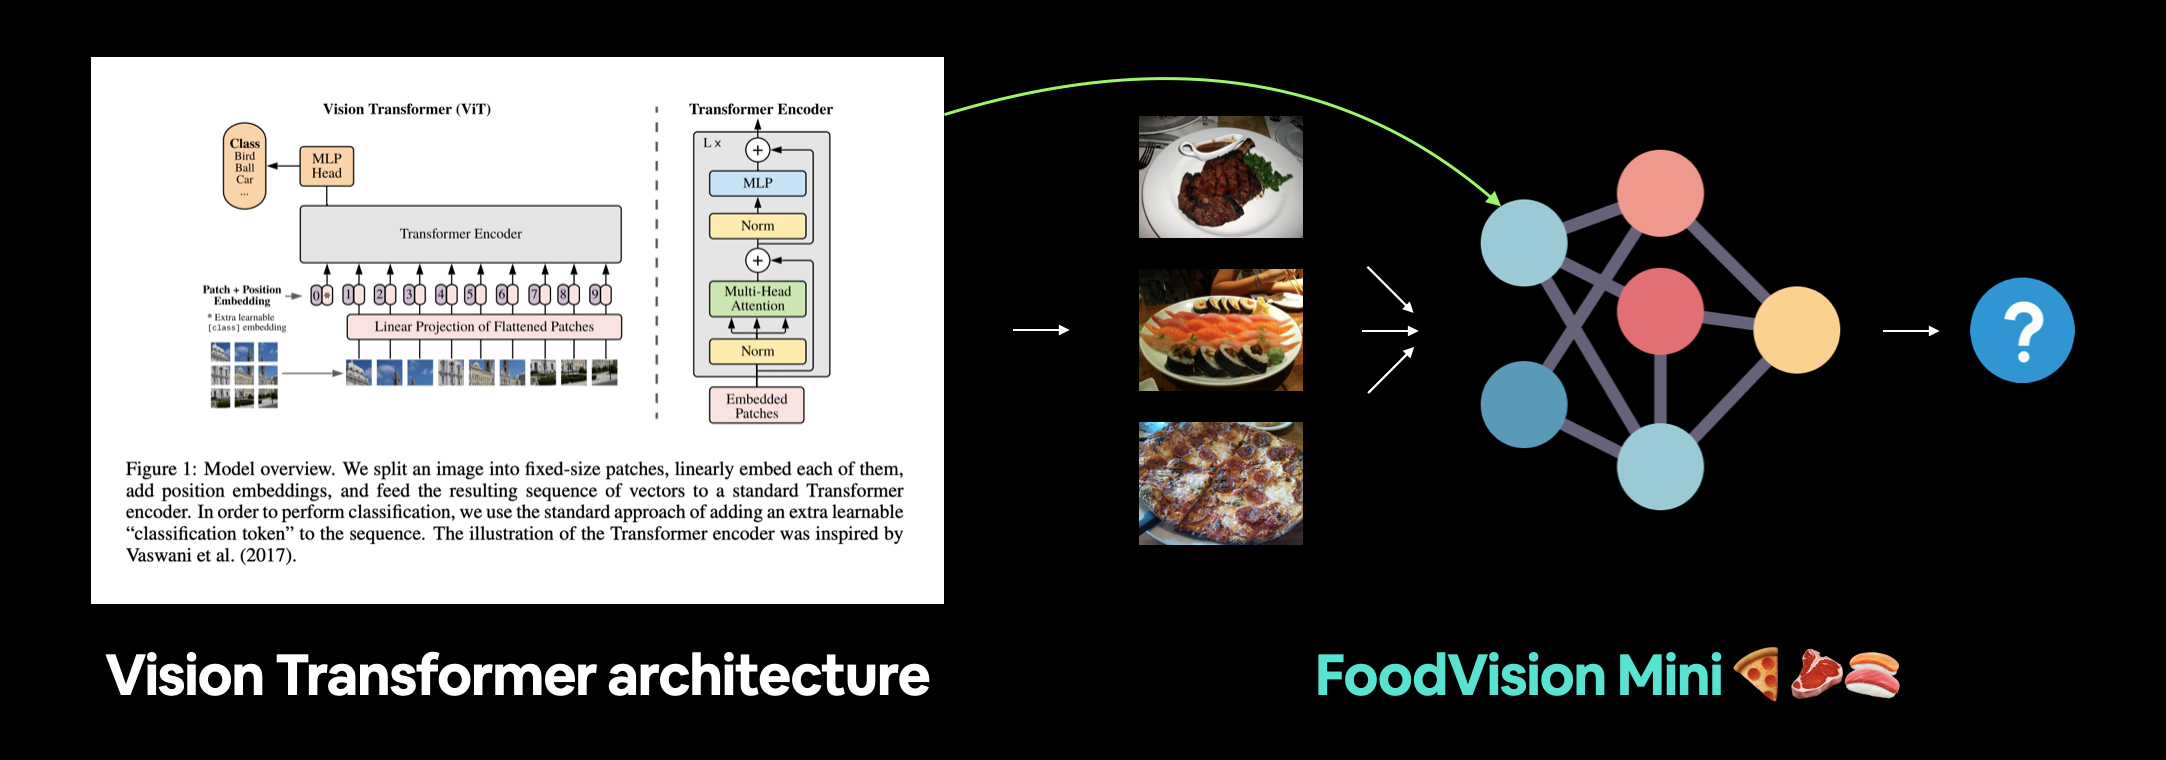

### What is paper replicating?

Many of these advances get published in machine learning research papers.

And the goal of paper replicating is to replicate these advances with code so you can use the techniques for your own problem.

For example, let's say a new model architecture gets released that performs better than any other architecture before on various benchmarks, wouldn't it be nice to try that architecture on your own problems?

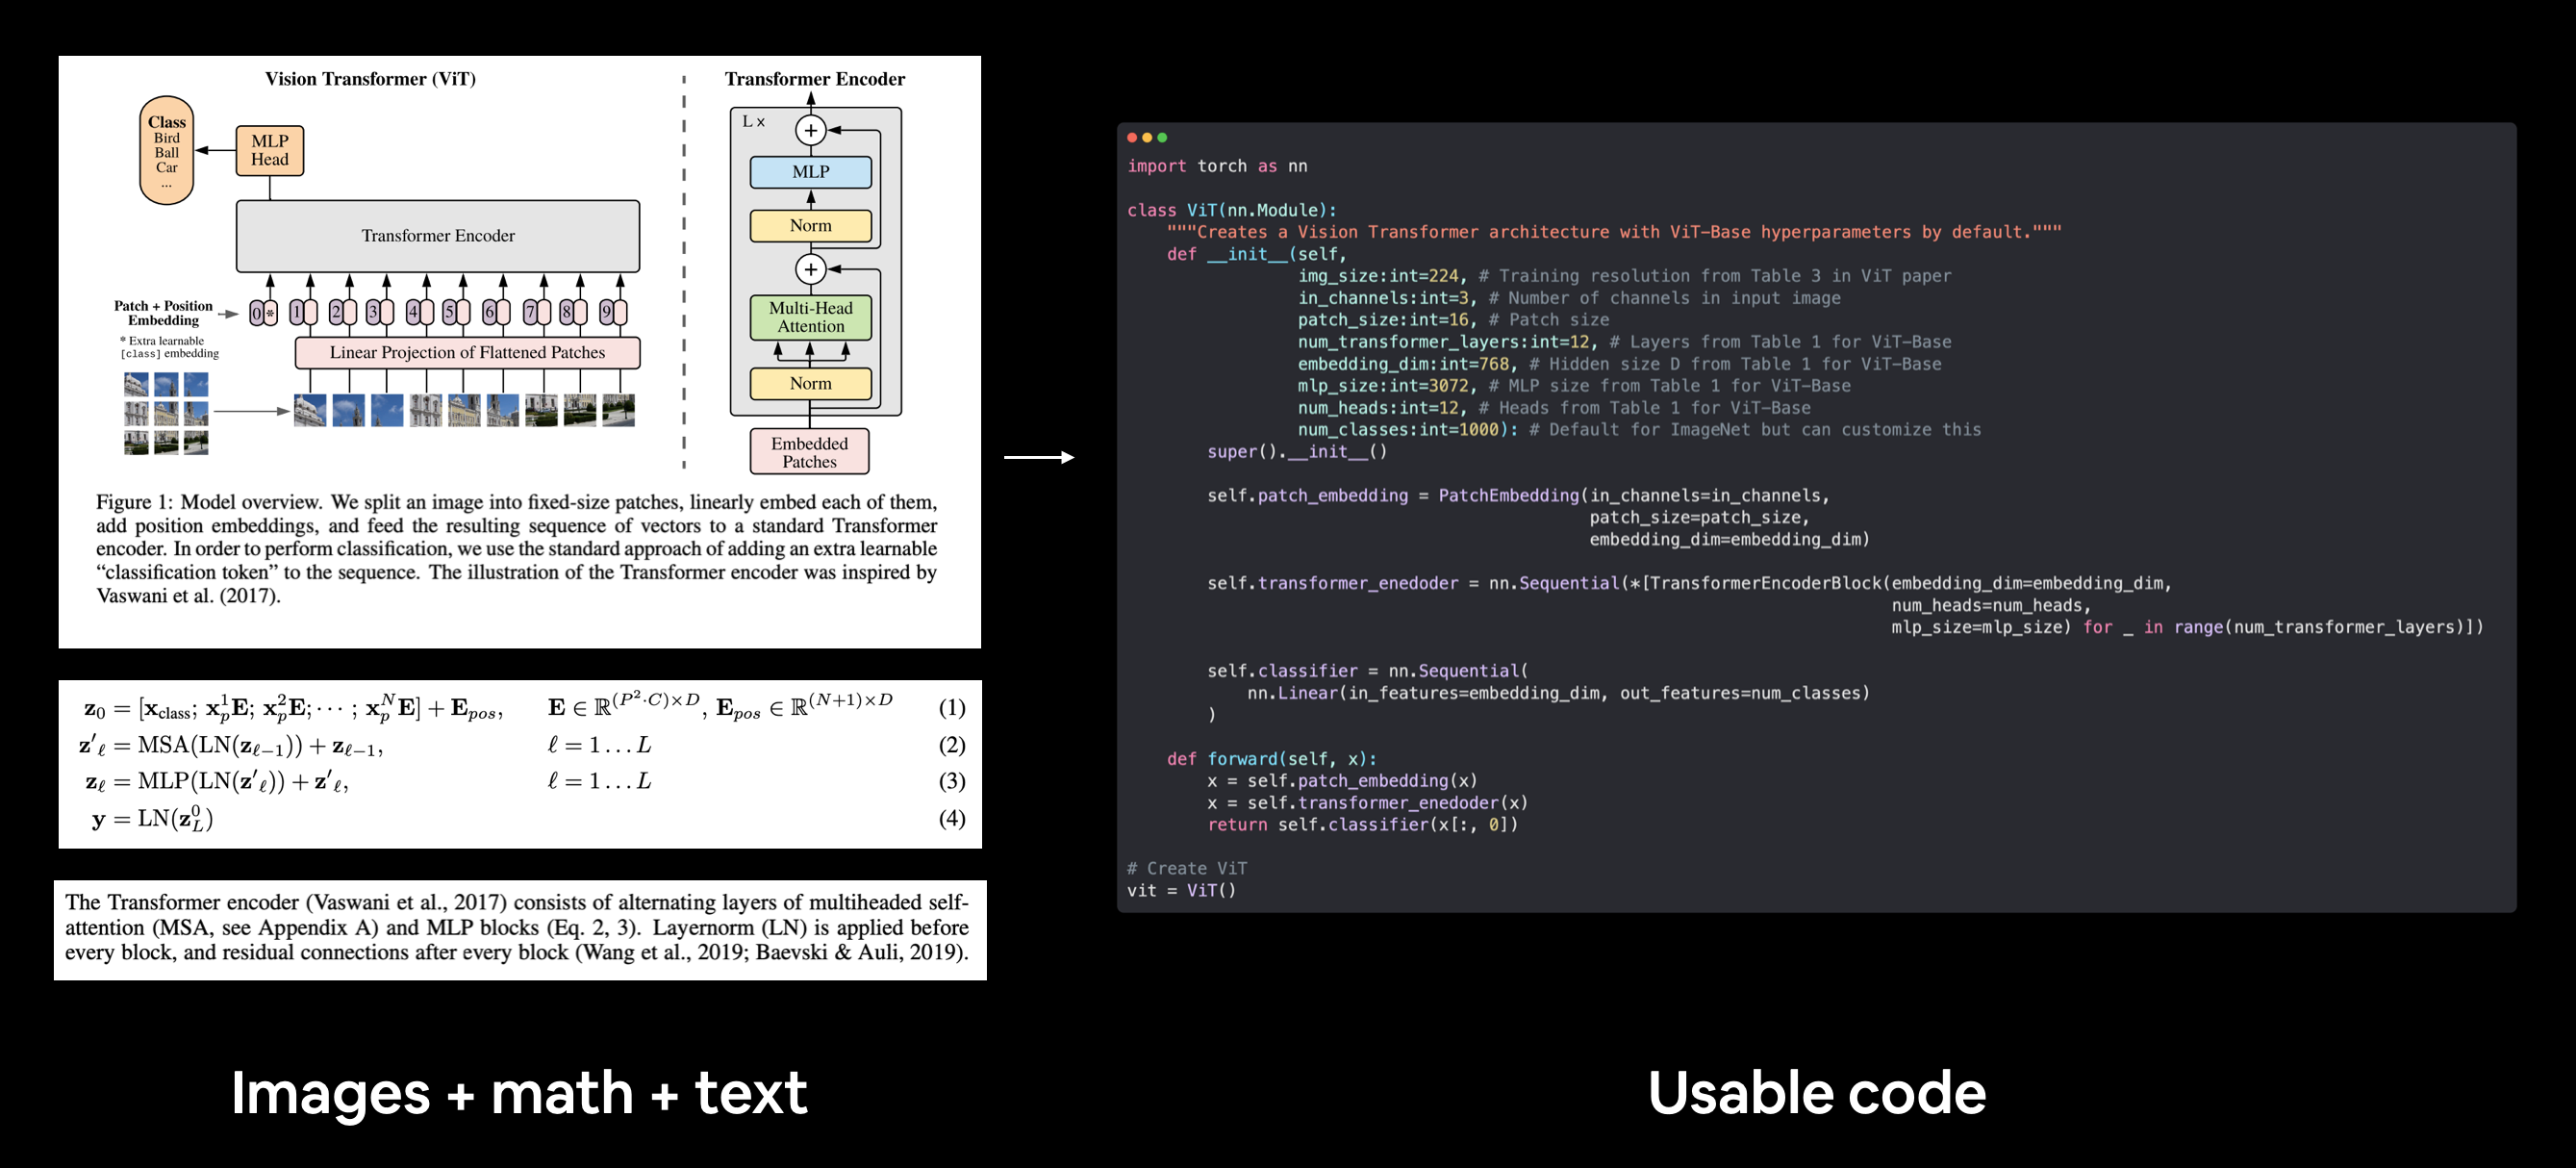

#### What is a machine learning research paper?

A machine learning research paper is a scientific paper that details findings of a research group on a specific area.

| Section | Contents |
| :--- | :--- |
| **Abstract** | An overview/summary of the paper's main findings/contributions. |
| **Introduction** | What's the paper's main problem and details of previous methods used to try and solve it. |
| **Method** | How did the researchers go about conducting their research? For example, what model(s), data sources, training setups were used? |
| **Results** | What are the outcomes of the paper? If a new type of model or training setup was used, how did the results of findings compare to previous works? (this is where **experiment tracking** comes in handy) |
| **Conclusion** | What are the limitations of the suggested methods? What are some next steps for the research community? |
| **References** | What resources/other papers did the researchers look at to build their own body of work? |
| **Appendix** | Are there any extra resources/findings to look at that weren't included in any of the above sections? |

## 0.Getting setup

In [1]:
import torch 
from torchinfo import summary
import matplotlib.pyplot as plt 
import torchvision
from torchvision import transforms
from torch import nn
import requests
from helper_function import download_data

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Get Data

In [3]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data\pizza_steak_sushi directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi')

In [4]:
train_dir = image_path / "train"
test_dir = image_path / "test"

## 2. Creating Datasets and Dataloaders

First, we'll create a transform to prepare our images.

This where one of the first references to the ViT paper will come in.

In Table 3, the training resolution is mentioned as being 224 (height=224, width=224).

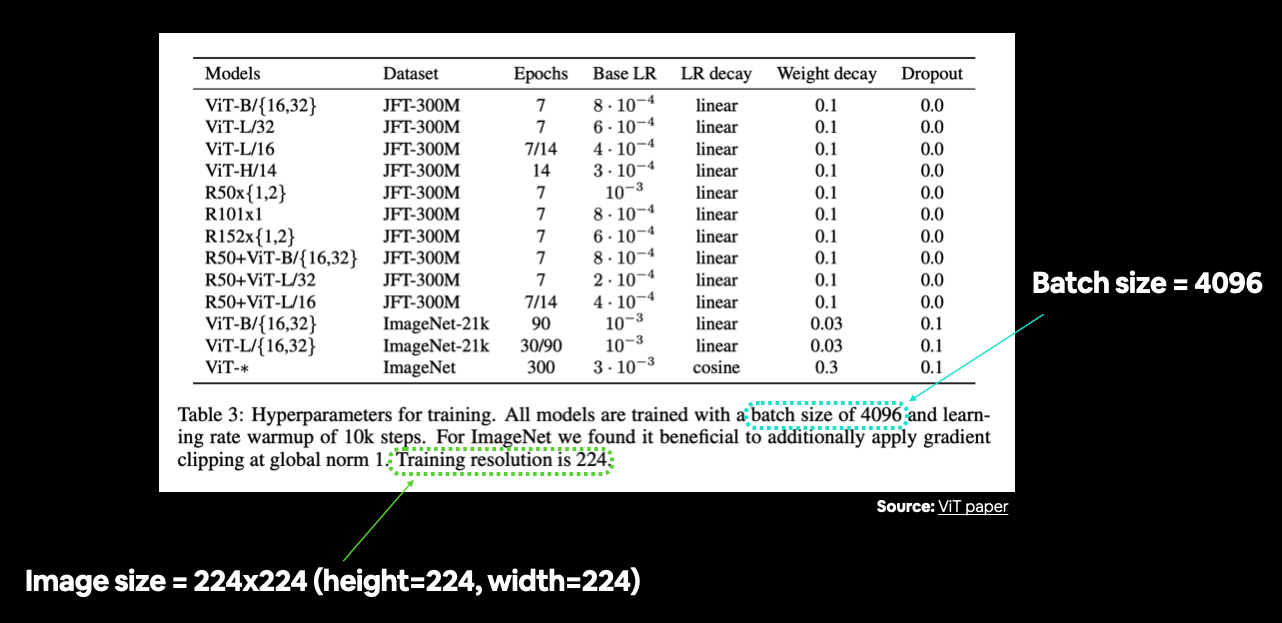

You can often find various hyperparameter settings listed in a table. In this case we're still preparing our data, so we're mainly concerned with things like image size and batch size. Source: Table 3 in ViT paper.

So we'll make sure our transform resizes our images appropriately.

And since we'll be training our model from scratch (no transfer learning to begin with), we won't provide a normalize transform like we did in 06. PyTorch Transfer Learning section 2.1.

### 2.1 Prepare transforms for images

In [5]:
IMG_SIZE = 224
manual_transform = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                    transforms.ToTensor()
])

print(f"Manually created transform : {manual_transform}")


Manually created transform : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Turn images into `Dataloader`'s

Transforms created!

Let's now create our DataLoader's.

The ViT paper states the use of a batch size of 4096 which is 128x the size of the batch size we've been using (32).

However, we're going to stick with a batch size of 32.


In [6]:
import data_setup

BATCH_SIZE = 32
train_dataloader , test_dataloader ,class_names , class_dict = data_setup.create_dataloaders(train_dir = train_dir,test_dir = test_dir,
train_transform =manual_transform,test_transform = manual_transform, batch_size = BATCH_SIZE)

train_dataloader,test_dataloader,class_names,class_dict

(<torch.utils.data.dataloader.DataLoader at 0x28192a974f0>,
 ['pizza', 'steak', 'sushi'],
 {'pizza': 0, 'steak': 1, 'sushi': 2})

### 2.3 Visualize a single image

Now we've loaded our data, let's visualize, visualize, visualize!

An important step in the ViT paper is preparing the images into patches.

In [7]:
image_batch,label_batch = next(iter(train_dataloader))

image,label = image_batch[0] , label_batch[0]

image.shape,label

(torch.Size([3, 224, 224]), tensor(0))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

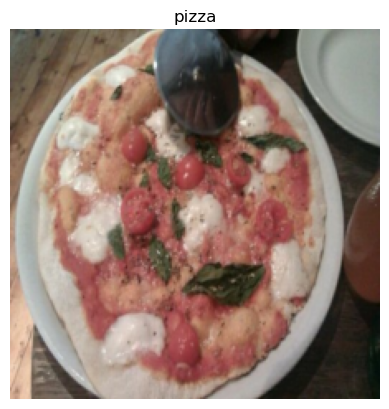

In [8]:
#plot the image with matplotlib
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

## 3.Replicating the vit paper : an overview

We'd like to replicate the ViT paper for our own problem, FoodVision Mini.

So our model inputs are: images of pizza, steak and sushi.

And our ideal model outputs are: predicted labels of pizza, steak or sushi.

No different to what we've been doing throughout the previous sections.

The question is: how do we go from our inputs to the desired outputs?

#### 3.1 Inputs and outputs , layers and blocks

ViT is a deep learning neural network architecture.

And any neural network architecture is generally comprised of layers.

And a collection of layers is often referred to as a block.

And stacking many blocks together is what gives us the whole architecture.

A layer takes an input (say an image tensor), performs some kind of function on it (for example what's in the layer's forward() method) and then returns an output.

So if a single layer takes an input and gives an output, then a collection of layers or a block also takes an input and gives an output.

Let's make this concrete : 

**Layer** - Takes an input, performs fucntions on it, returns an ouput.

**Block** - A collection of layers, takes an input, performs a series of functions on it, returns an output. 

**Architecture (or Model)** - a collection of blocks, takes an input, performs a series of functions on it, returns an output.

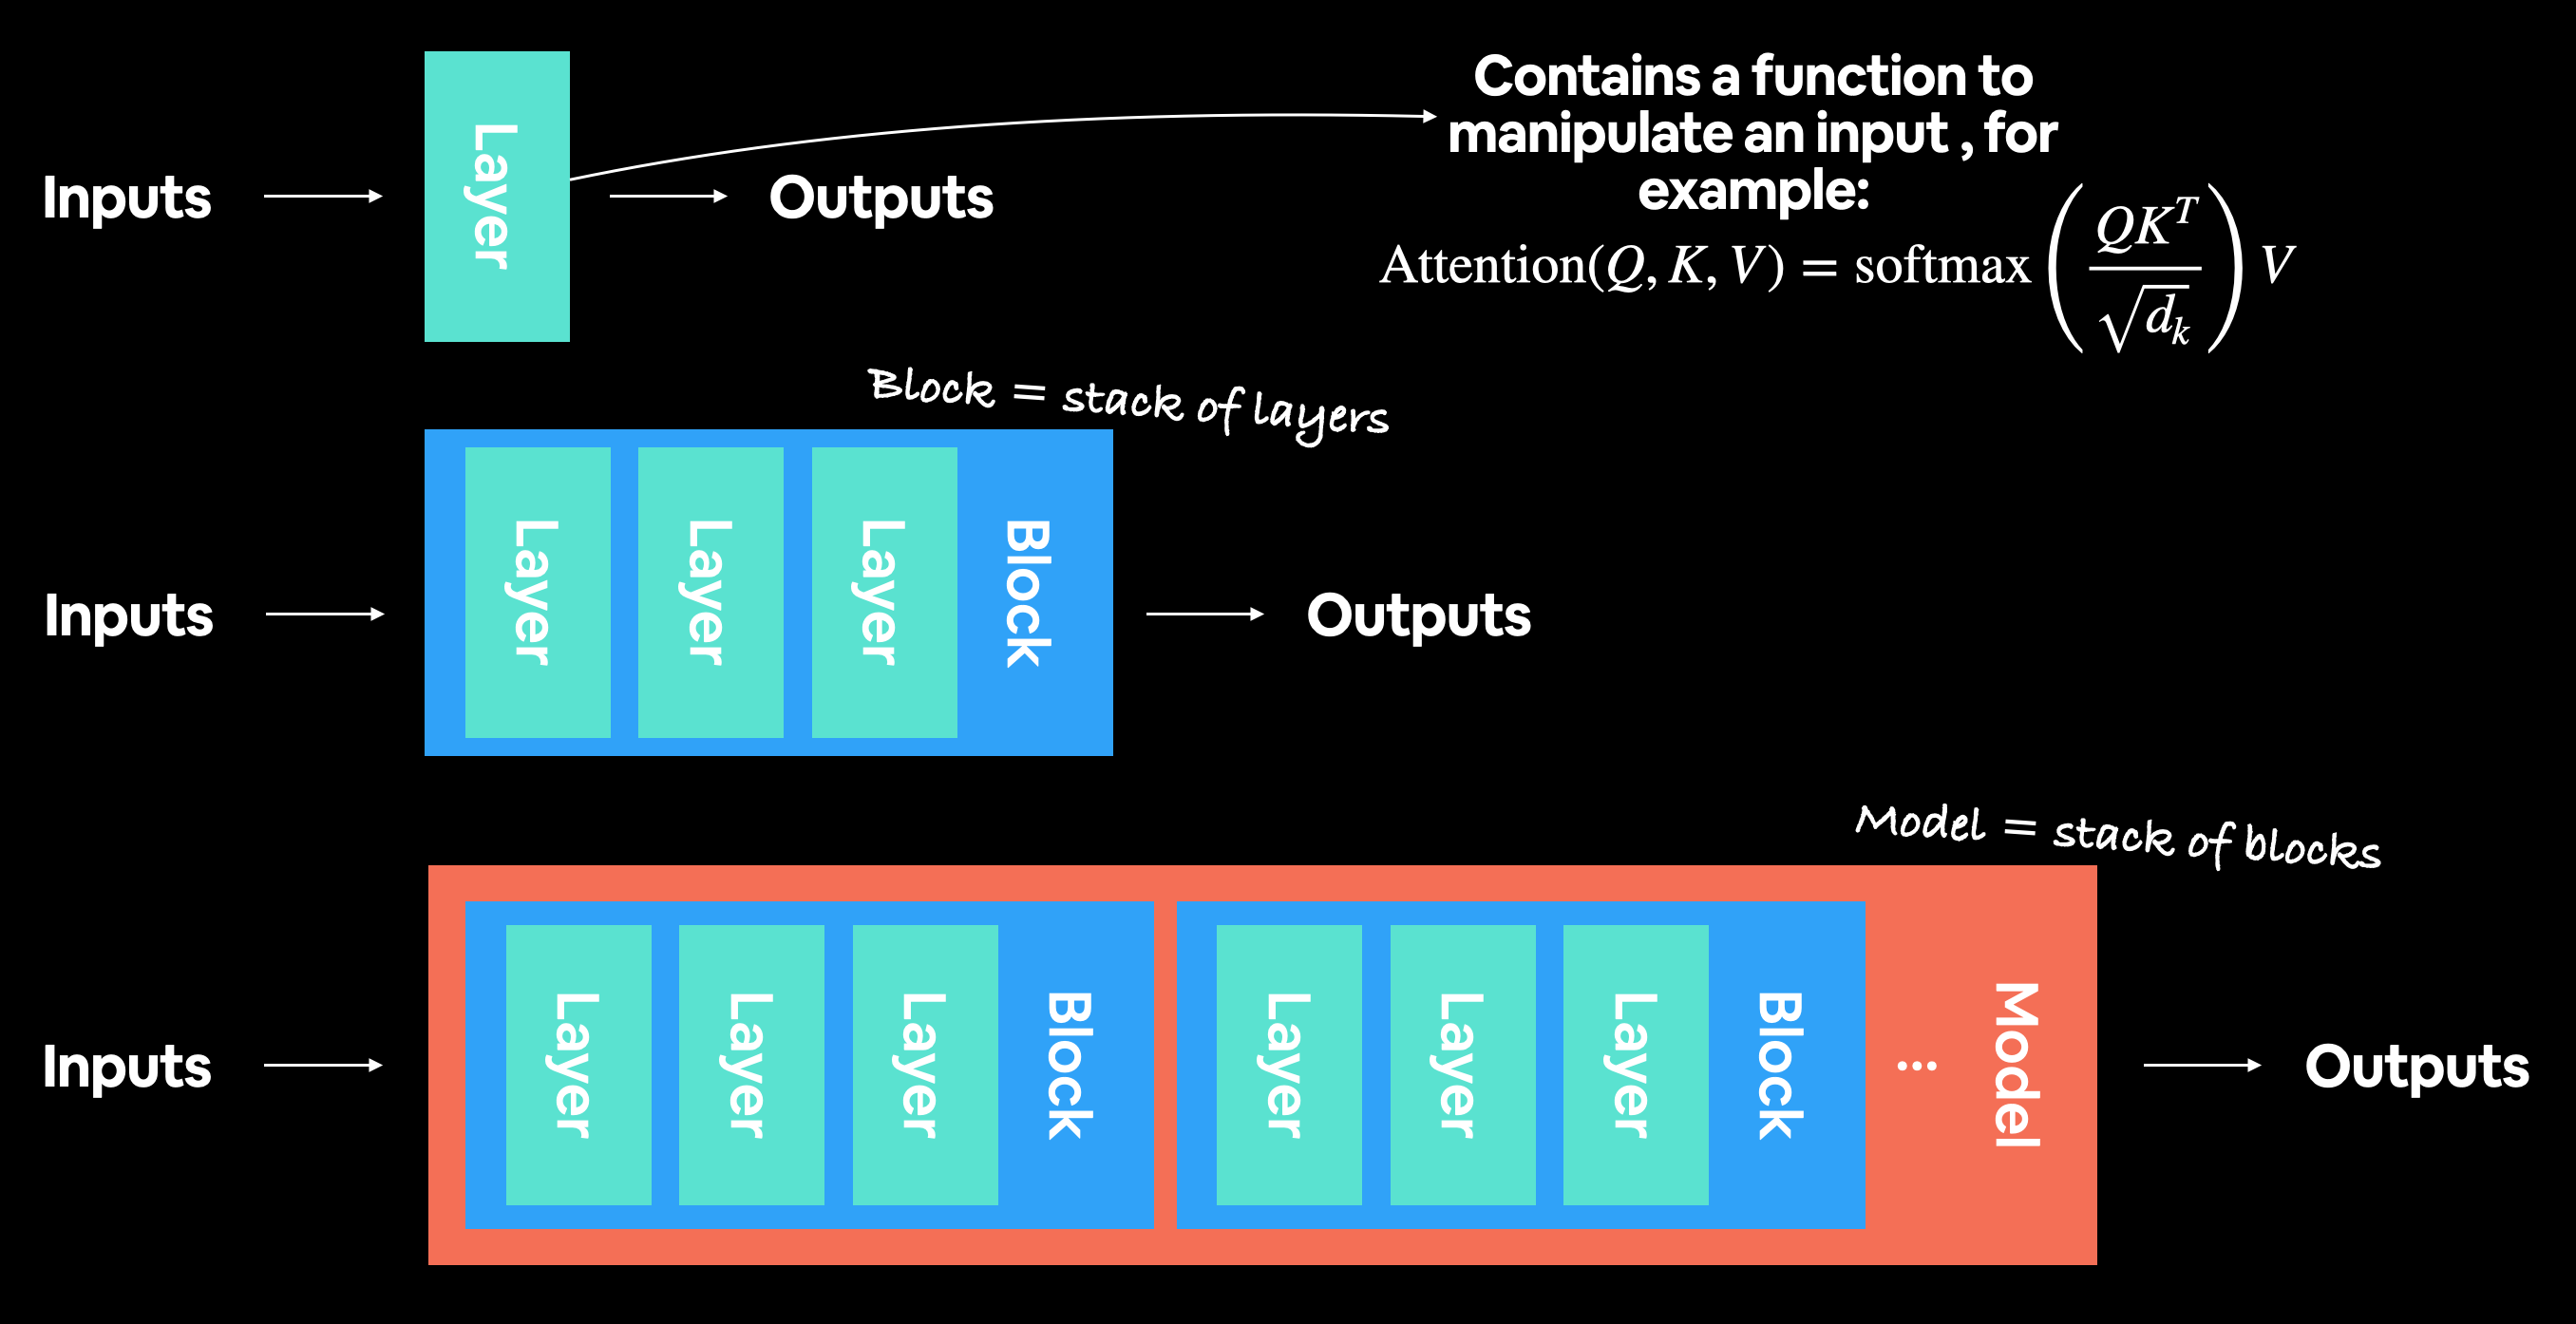

### 4.1 Calculating path embeddings and input and output shapes by hand





In [9]:
height = 224
width = 224 
color_channels = 3
patch_size = 16 
number_of_patches = int((height * width )/patch_size **2)
print(f"Number of patches (N) with image\nHeight : {height}\nWidth : {width}\nPatch size : {patch_size}\nNumber of patches : {number_of_patches} ")

Number of patches (N) with image
Height : 224
Width : 224
Patch size : 16
Number of patches : 196 


**Input**: The image starts as 2D with size ${H \times W \times C}$.

**Output**: The image gets converted to a sequence of flattened 2D patches with size ${N \times\left(P^{2} \cdot C\right)}$.




In [10]:
embedding_layer_input_shape = (height,width,color_channels)
embedding_layer_output_shape = (number_of_patches,patch_size**2 * color_channels)
print(f"Inpput shape (single 2d image) : {embedding_layer_input_shape}")
print(f"Output shape (Single 2d image flattened into patches) : {embedding_layer_output_shape}")

Inpput shape (single 2d image) : (224, 224, 3)
Output shape (Single 2d image flattened into patches) : (196, 768)


### 4.2 Turning a single image into patches

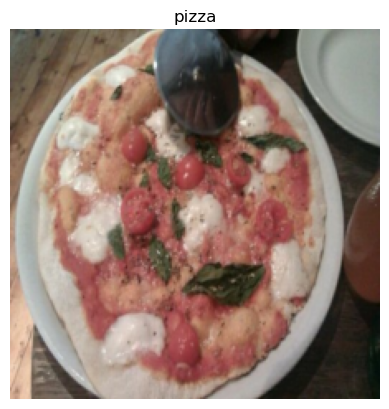

In [11]:
#Visualizing a single image
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False);

(np.float64(-0.5), np.float64(223.5), np.float64(15.5), np.float64(-0.5))

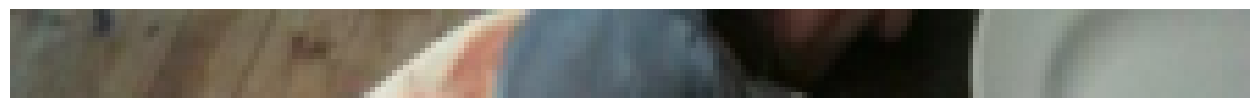

In [12]:
#Chnage image shape to be compatilbe with matplotlib
image_permuted = image.permute(1,2,0)
patch_size = 16
plt.figure(figsize=(patch_size,patch_size))
plt.imshow(image_permuted[:patch_size,:,:])#imshow(rows,cols,color channels)
plt.axis(False)

Number of patches per row : 14.0
Patch size : 16 pixels x 16 pixels


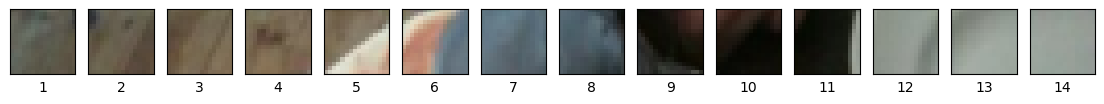

In [13]:
#Setting up hyperparameters
img_size = 224
patch_size = 16 
num_patches = img_size / patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
fig, axs = plt.subplots(nrows = 1,ncols = img_size // patch_size , figsize = (num_patches,num_patches),
sharex = True, sharey = True)

print(f"Number of patches per row : {num_patches}\nPatch size : {patch_size} pixels x {patch_size} pixels")

for  i , patch in enumerate(range(0,img_size,patch_size)):
    axs[i].imshow(image_permuted[:patch_size,patch:patch+patch_size,:]);
    axs[i].set_xlabel(i+1)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

#### Converting the whole image into patches

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


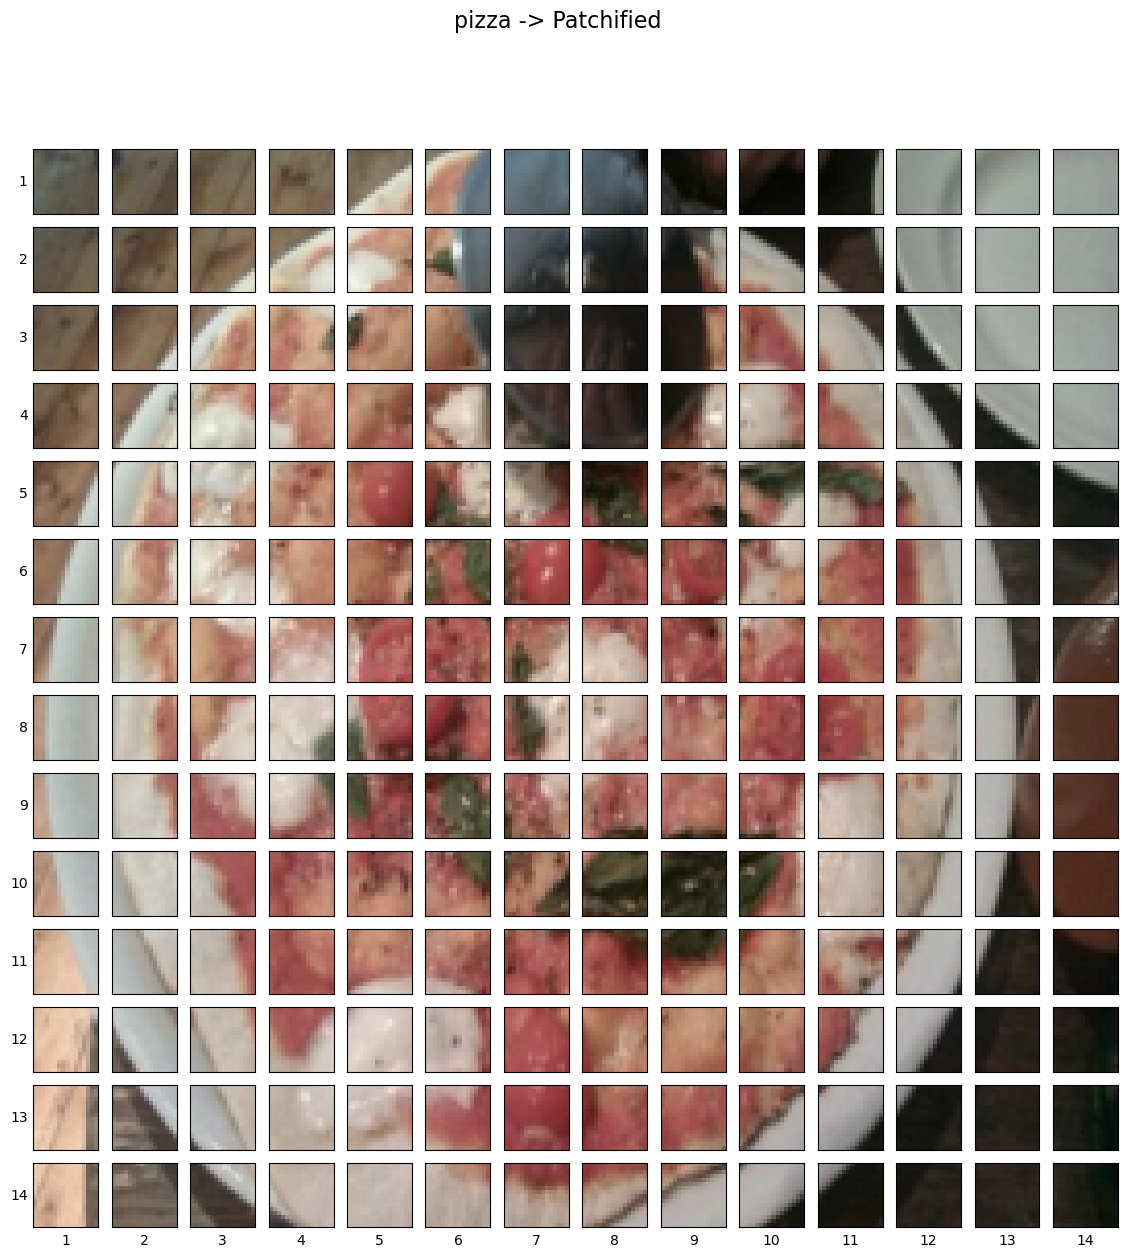

In [14]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

### 4.3 Creating image patches with `torch.nn.Conv2d()`

In [15]:
from torch import nn
patch_size = 16 
conv2d = nn.Conv2d(in_channels= 3, out_channels= 768
, kernel_size= patch_size,stride = patch_size ,padding = 0)

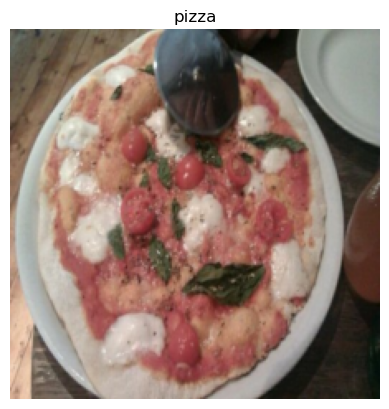

In [16]:
#View single image
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False);

In [17]:
#Passin the image through the convolutional feature map
img_out_of_conv = conv2d(image.unsqueeze(0))
print(f"{img_out_of_conv.shape} : [batch_size , embedding_dim , feature map height , feature map width]")

torch.Size([1, 768, 14, 14]) : [batch_size , embedding_dim , feature map height , feature map width]


Showing random convolutional feature maps from indexes: [732, 20, 636, 205, 596]


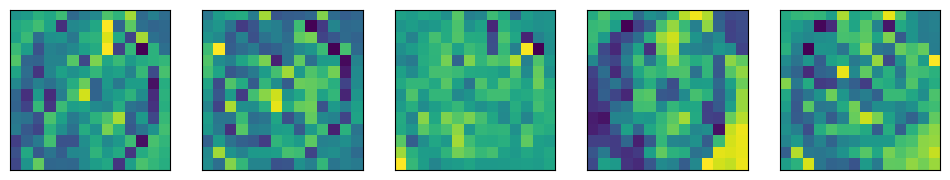

In [18]:
#Visulazing 5 random convolutional feature maps
import random
random_indexes = random.sample(range(0,758), k = 5)
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

for i , idx  in enumerate(random_indexes):
    image_conv_feature_map = img_out_of_conv[:, idx, :, :] # index on the output tensor of the convolutional layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

In [19]:
#Getting a single feature map in tensor form

single_feature_map = img_out_of_conv[:,0,:,:]
single_feature_map , single_feature_map.requires_grad


(tensor([[[ 0.1621,  0.1879,  0.2479,  0.2495,  0.4910,  0.2036,  0.1774,
            0.1131,  0.0631,  0.0021,  0.2658,  0.2273,  0.3271,  0.2909],
          [ 0.2348,  0.2260,  0.3547,  0.5011,  0.3304,  0.1278,  0.1487,
            0.0188,  0.2567,  0.4036,  0.1164,  0.3241,  0.3077,  0.2801],
          [ 0.2018,  0.3573,  0.2443,  0.2232,  0.3038,  0.1042,  0.1487,
            0.0922,  0.2941,  0.2792,  0.3638,  0.1902,  0.3143,  0.2877],
          [ 0.2895,  0.4038,  0.3860,  0.3566,  0.2292,  0.2834,  0.1569,
            0.0971,  0.4603,  0.2168,  0.3015,  0.1526,  0.2047,  0.2896],
          [ 0.4276,  0.3399,  0.2664,  0.3344,  0.1685,  0.2298,  0.2492,
            0.2194,  0.3271,  0.4313,  0.2467,  0.3849,  0.0741, -0.0750],
          [ 0.3307,  0.4469,  0.4212,  0.3189,  0.3066,  0.1691,  0.2269,
            0.3460,  0.2366,  0.2995,  0.2529,  0.3942,  0.0914,  0.2113],
          [ 0.3487,  0.3387,  0.2567,  0.4364,  0.2399,  0.3150,  0.4333,
            0.3889,  0.3258,  0.

### 4.4 Flattening the patch embeddings with `torch.nn.Flatten()`

We have turned the images into embeddings but they are in 2d format 

Desired output (1D sequence of flattened 2D patches): (196, 768) -> (number of patches, embedding dimension) -> ${N \times\left(P^{2} \cdot C\right)}$

In [20]:
# Current tensor shape
print(f"Current tensor shape: {img_out_of_conv.shape} -> [batch, embedding_dim, feature_map_height, feature_map_width]")

Current tensor shape: torch.Size([1, 768, 14, 14]) -> [batch, embedding_dim, feature_map_height, feature_map_width]


In [21]:
flatten = nn.Flatten(start_dim=2 , #Flatten feature map height 
end_dim= 3 )#Flatten feature map width


Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


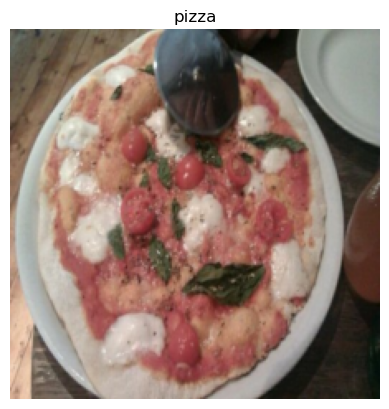

In [22]:
# 1. View single image
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);
print(f"Original image shape: {image.shape}")

# 2. Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension to avoid shape errors
print(f"Image feature map shape: {image_out_of_conv.shape}")

# 3. Flatten the feature maps
image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [23]:
#Get flattened image patch embeddings in right shape
img_out_of_conv_flat_reshape = image_out_of_conv_flattened.permute(0,2,1)
print(f"Patch embedding  sequence shape : {img_out_of_conv_flat_reshape.shape} -> [batch_size,num_patches,emebdding_size]")


Patch embedding  sequence shape : torch.Size([1, 196, 768]) -> [batch_size,num_patches,emebdding_size]


In [24]:
#Get a single flattened feature map
single_flattened_feature_map = img_out_of_conv_flat_reshape

### 4.5 Turning the vit patch embedding layer into a pytorch module

In [25]:
# 1. Create a class which subclasses nn.Module
class PatchEmbedding(nn.Module):
    """Turns a 2D input image into a 1D sequence learnable embedding vector.

    Args:
        in_channels (int): Number of color channels for the input images. Defaults to 3.
        patch_size (int): Size of patches to convert input image into. Defaults to 16.
        embedding_dim (int): Size of embedding to turn image into. Defaults to 768.
    """
    # 2. Initialize the class with appropriate variables
    def __init__(self,
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=768):
        super().__init__()

        # 3. Create a layer to turn an image into patches
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        # 4. Create a layer to flatten the patch feature maps into a single dimension
        self.flatten = nn.Flatten(start_dim=2, # only flatten the feature map dimensions into a single vector
                                  end_dim=3)

    # 5. Define the forward method
    def forward(self, x):
        # Create assertion to check that inputs are the correct shape
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size == 0, f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {patch_size}"

        # Perform the forward pass
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        # 6. Make sure the output shape has the right order
        return x_flattened.permute(0, 2, 1) # adjust so the embedding is on the final dimension [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]